# Monthly Demand Forecasting

We predict completed sales for each store and product category, one month ahead.

The notebook follows six steps:

1. Load sales and add missing months.
2. Explore sales patterns.
3. Create features from past sales.
4. Compare two models and three simple baselines.
5. Check errors on later months.
6. Save the results.

This simpler version uses the small feature set and model settings selected in an earlier validation experiment. It does not repeat the large model search. The old experiment output files are not needed for this notebook.

Our target is **recorded completed sales**. It is not all customer demand. We assume that earlier sales totals are available before the next month starts. Historical stock levels and past order-status snapshots are not available here.

## 1. Load and Prepare the Data

We use January 2016 to March 2018: 27 months, 3 stores, and 7 categories.

April 2018 has no completed orders in this dataset. We exclude it because treating unfinished orders as zero demand would be misleading.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

### Project Folder and Dates

The notebook can run from the project folder or the `notebooks` folder. The database settings are loaded by the existing project function.

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "src" / "database.py").exists():
    raise FileNotFoundError("Please run from the project folder or notebooks folder.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.database import create_db_engine

START_DATE = "2016-01-01"
END_DATE = "2018-03-01"
TRAIN_START = "2016-04-01"
VALIDATION_MONTHS = pd.date_range("2017-07-01", "2017-12-01", freq="MS")
TEST_MONTHS = pd.date_range("2018-01-01", "2018-03-01", freq="MS")

### Read Completed Sales

The query returns one row for each store, category, and month with completed sales. We only need units sold and the names used in charts.

In [3]:
query = """
    SELECT
        DATE_FORMAT(order_date, '%%Y-%%m-01') AS month_start,
        store_id, store_name, category_id, category_name,
        SUM(realized_units_sold) AS units_sold
    FROM vw_excel_order_items
    WHERE order_date >= %(start)s
      AND order_date < %(end)s
      AND is_completed = 1
    GROUP BY DATE_FORMAT(order_date, '%%Y-%%m-01'),
             store_id, store_name, category_id, category_name
    ORDER BY store_id, category_id, month_start
"""

engine = create_db_engine()
try:
    demand = pd.read_sql_query(
        query, engine, params={"start": START_DATE, "end": "2018-04-01"}
    )
finally:
    engine.dispose()

demand["month_start"] = pd.to_datetime(demand["month_start"])
demand["units_sold"] = demand["units_sold"].astype(int)
store_map = demand[["store_id", "store_name"]].drop_duplicates()
category_map = demand[["category_id", "category_name"]].drop_duplicates()
demand.head()

,month_start,store_id,store_name,category_id,category_name,units_sold
0,2016-01-01,1,Santa Cruz Bikes,1,Children Bicycles,6
1,2016-02-01,1,Santa Cruz Bikes,1,Children Bicycles,8
2,2016-03-01,1,Santa Cruz Bikes,1,Children Bicycles,2
3,2016-04-01,1,Santa Cruz Bikes,1,Children Bicycles,6
4,2016-05-01,1,Santa Cruz Bikes,1,Children Bicycles,3


### Add Missing Months

We create every store-category-month combination. There should be **3 x 7 x 27 = 567 rows**.

A missing row means no completed sale was recorded in the query. We fill its sales value with zero. This assumes the source data is complete; it does not tell us whether a product was in stock.

We never use a future first sale to decide when a series starts.

In [4]:
keys = ["store_id", "category_id", "month_start"]
group_columns = ["store_id", "category_id"]
months = pd.date_range(START_DATE, END_DATE, freq="MS")
stores = sorted(demand["store_id"].unique())
categories = sorted(demand["category_id"].unique())

assert len(stores) == 3 and len(categories) == 7 and len(months) == 27
assert not demand.duplicated(keys).any()
assert set(demand["month_start"]) == set(months)

calendar = pd.MultiIndex.from_product([stores, categories, months], names=keys)
calendar = calendar.to_frame(index=False)

monthly_sales = calendar.merge(
    demand[keys + ["units_sold"]], on=keys, how="left", validate="one_to_one"
)
missing_months = monthly_sales["units_sold"].isna().sum()
monthly_sales["units_sold"] = monthly_sales["units_sold"].fillna(0).astype(int)
monthly_sales = monthly_sales.sort_values(keys).reset_index(drop=True)

assert len(monthly_sales) == 567
assert monthly_sales.groupby(group_columns).size().eq(27).all()
assert monthly_sales["units_sold"].ge(0).all()
assert monthly_sales["units_sold"].sum() == demand["units_sold"].sum()

print("Original rows:", len(demand))
print("Added zero-sales months:", missing_months)
print("Complete monthly rows:", len(monthly_sales))

Original rows: 470
Added zero-sales months: 97
Complete monthly rows: 567


### Quick Data Check

We check missing values and the sales range after completing the calendar. These checks can find merge problems, but cannot prove that every transaction reached the database.

In [5]:
display(monthly_sales.isna().sum().rename("Missing values"))
display(monthly_sales["units_sold"].describe())
monthly_sales["year"] = monthly_sales["month_start"].dt.year
monthly_sales["month"] = monthly_sales["month_start"].dt.month

store_id       0
category_id    0
month_start    0
units_sold     0
Name: Missing values, dtype: int64

count   567.000
mean     11.143
std      14.044
min       0.000
25%       2.000
50%       6.000
75%      14.000
max      70.000
Name: units_sold, dtype: float64

## 2. Explore Sales Patterns

### Sales Distribution

This chart includes zero-sales months. Many values are small, while a few are much larger.

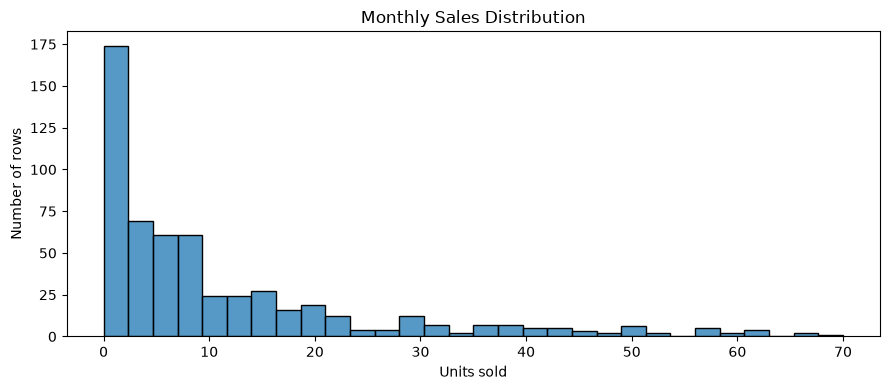

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=monthly_sales, x="units_sold", bins=30, ax=ax)
ax.set(title="Monthly Sales Distribution", xlabel="Units sold", ylabel="Number of rows")
plt.tight_layout()
plt.show()

### Total Monthly Sales

We add sales across all stores and categories. An active series is a store-category pair with positive sales in that month.

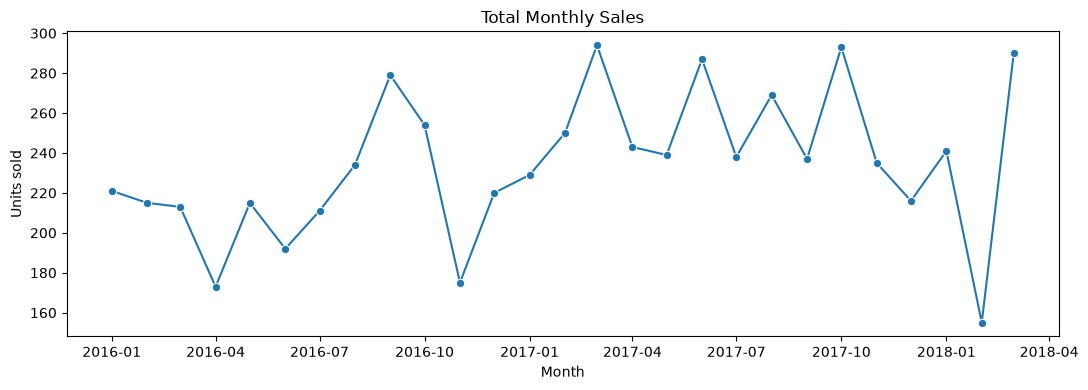

In [7]:
monthly_totals = monthly_sales.groupby("month_start", as_index=False).agg(
    units_sold=("units_sold", "sum"),
    active_series=("units_sold", lambda sales: (sales > 0).sum()),
)

fig, ax = plt.subplots(figsize=(11, 4))
sns.lineplot(data=monthly_totals, x="month_start", y="units_sold", marker="o", ax=ax)
ax.set(title="Total Monthly Sales", xlabel="Month", ylabel="Units sold")
plt.tight_layout()
plt.show()

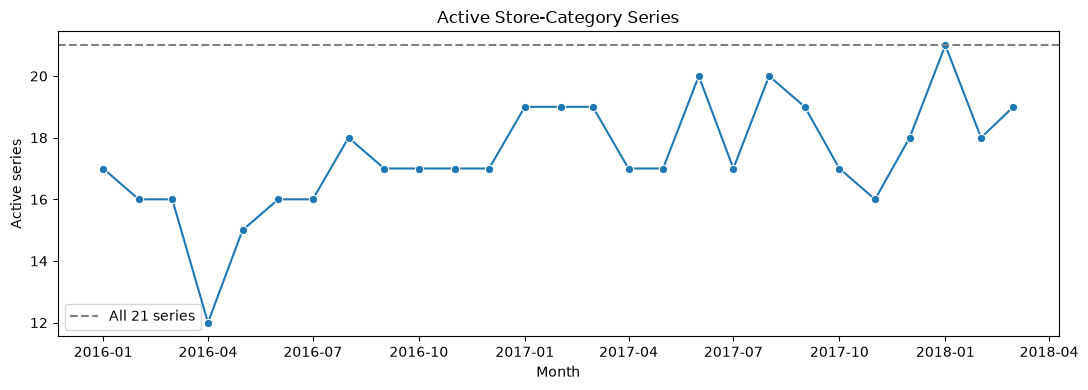

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.lineplot(data=monthly_totals, x="month_start", y="active_series", marker="o", ax=ax)
ax.axhline(21, linestyle="--", color="gray", label="All 21 series")
ax.set(title="Active Store-Category Series", xlabel="Month", ylabel="Active series")
ax.legend()
plt.tight_layout()
plt.show()

### Yearly and Seasonal Patterns

The yearly table includes only January to March for 2018. Do not compare its total directly with a full year.

For seasonality, we compare 2016 and 2017. Two full years are not enough to confirm a stable yearly pattern.

,year,units_sold
0,2016,2602
1,2017,3030
2,2018,686


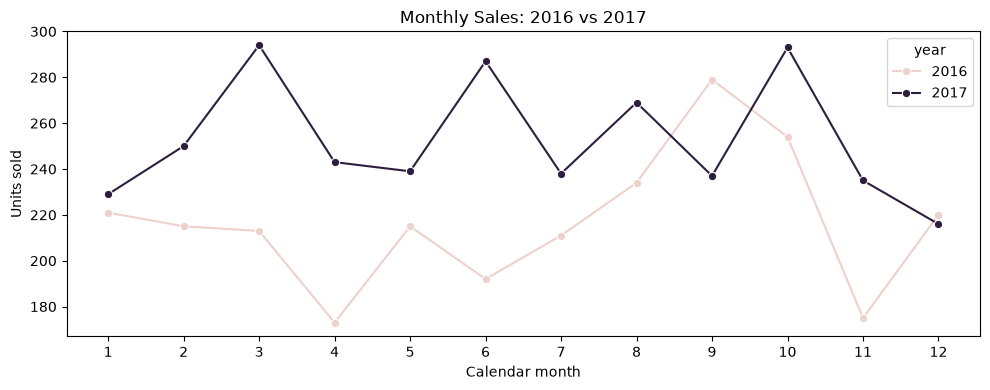

In [9]:
yearly_totals = monthly_sales.groupby("year", as_index=False)["units_sold"].sum()
display(yearly_totals)

full_years = monthly_sales[monthly_sales["year"].isin([2016, 2017])]
year_month_sales = full_years.groupby(["year", "month"], as_index=False)["units_sold"].sum()

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=year_month_sales, x="month", y="units_sold", hue="year", marker="o", ax=ax)
ax.set(title="Monthly Sales: 2016 vs 2017", xlabel="Calendar month", ylabel="Units sold")
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

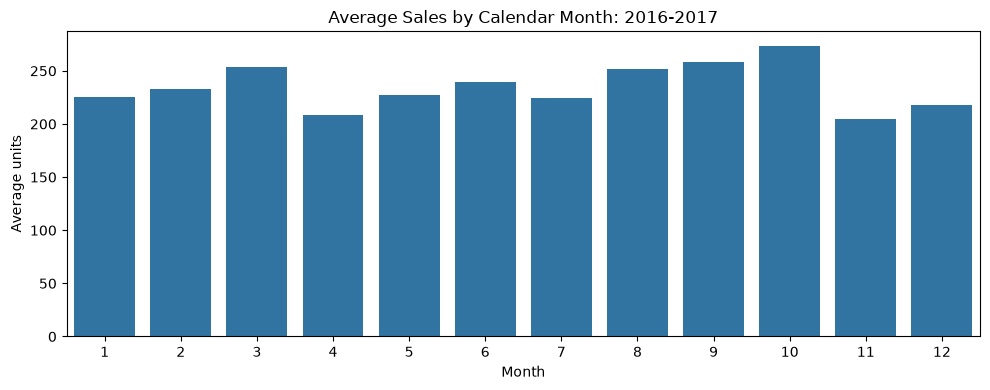

In [10]:
seasonal_average = year_month_sales.groupby("month", as_index=False)["units_sold"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=seasonal_average, x="month", y="units_sold", ax=ax)
ax.set(title="Average Sales by Calendar Month: 2016-2017", xlabel="Month", ylabel="Average units")
plt.tight_layout()
plt.show()

### Store Patterns

Baldwin Bikes has the largest sales total. Stores have different sales levels, so store information is useful for the model.

Average sales below include all category-month rows, including zeros.

,store_id,total_units,average_units,store_name
0,1,1236,6.540,Santa Cruz Bikes
1,2,4427,23.423,Baldwin Bikes
2,3,655,3.466,Rowlett Bikes


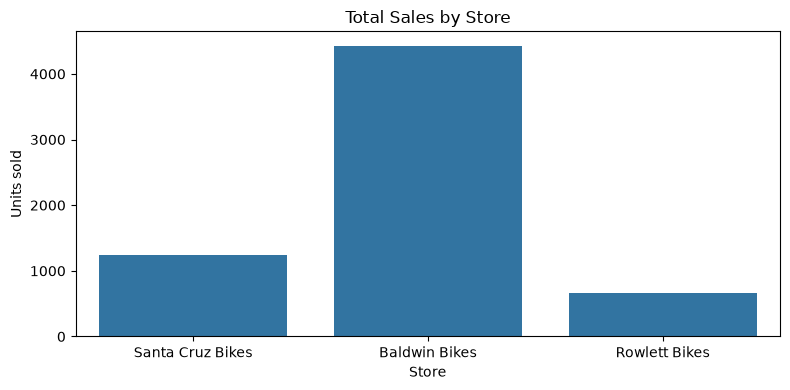

In [11]:
store_summary = monthly_sales.groupby("store_id", as_index=False).agg(
    total_units=("units_sold", "sum"), average_units=("units_sold", "mean")
)
store_summary = store_summary.merge(store_map, on="store_id")
display(store_summary)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=store_summary, x="store_name", y="total_units", ax=ax)
ax.set(title="Total Sales by Store", xlabel="Store", ylabel="Units sold")
plt.tight_layout()
plt.show()

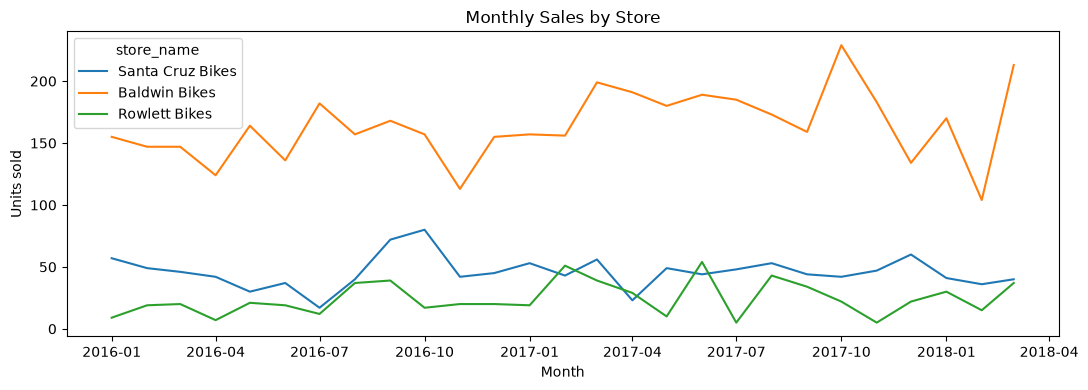

In [12]:
store_monthly = monthly_sales.groupby(["month_start", "store_id"], as_index=False)["units_sold"].sum()
store_monthly = store_monthly.merge(store_map, on="store_id")

fig, ax = plt.subplots(figsize=(11, 4))
sns.lineplot(data=store_monthly, x="month_start", y="units_sold", hue="store_name", ax=ax)
ax.set(title="Monthly Sales by Store", xlabel="Month", ylabel="Units sold")
plt.tight_layout()
plt.show()

### Category Patterns

Cruisers Bicycles and Mountain Bikes have high total sales. Electric Bikes and Cyclocross Bicycles have lower totals.

Some categories have long periods with zero completed sales. Historical product availability is unknown, so we do not label these periods as stockouts or product launches.

,category_id,total_units,average_units,category_name
2,3,1865,23.025,Cruisers Bicycles
5,6,1607,19.840,Mountain Bikes
0,1,1047,12.926,Children Bicycles
1,2,733,9.049,Comfort Bicycles
6,7,449,5.543,Road Bikes
3,4,365,4.506,Cyclocross Bicycles
4,5,252,3.111,Electric Bikes


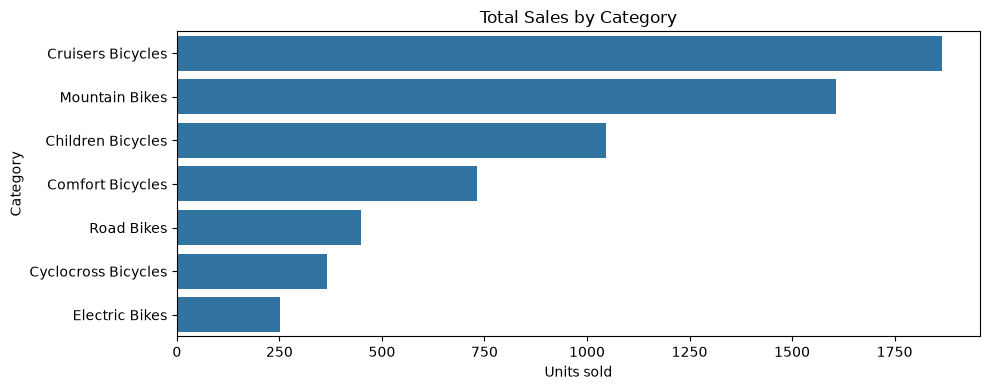

In [13]:
category_summary = monthly_sales.groupby("category_id", as_index=False).agg(
    total_units=("units_sold", "sum"), average_units=("units_sold", "mean")
)
category_summary = category_summary.merge(category_map, on="category_id")
category_summary = category_summary.sort_values("total_units", ascending=False)
display(category_summary)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=category_summary, x="total_units", y="category_name", ax=ax)
ax.set(title="Total Sales by Category", xlabel="Units sold", ylabel="Category")
plt.tight_layout()
plt.show()

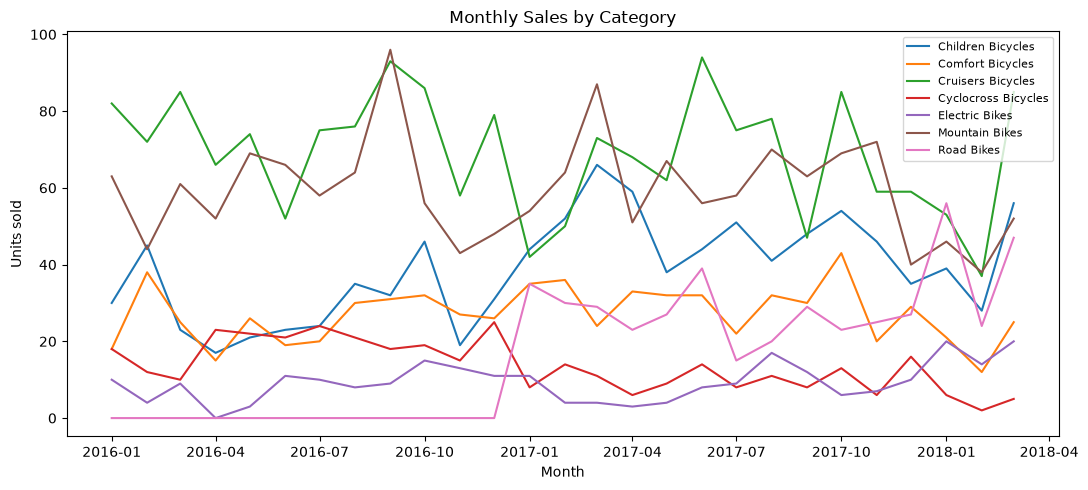

In [14]:
category_monthly = monthly_sales.groupby(["month_start", "category_id"], as_index=False)["units_sold"].sum()
category_monthly = category_monthly.merge(category_map, on="category_id")

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=category_monthly, x="month_start", y="units_sold", hue="category_name", ax=ax)
ax.set(title="Monthly Sales by Category", xlabel="Month", ylabel="Units sold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Create Past-Sales Features

`lag_1` means last month's sales for the same store and category. We also use lags 2 and 3, plus means of the previous 3 and 6 months.

We calculate lag 12 for the seasonal baseline only. We add no random noise. The first three months provide history; model training starts in April 2016.

In [15]:
def add_sales_features(data):
    data = data.sort_values(keys).copy()
    sales_by_group = data.groupby(group_columns)["units_sold"]

    for lag in [1, 2, 3, 12]:
        data[f"lag_{lag}"] = sales_by_group.shift(lag)

    for window in [3, 6]:
        data[f"rolling_mean_{window}"] = sales_by_group.transform(
            lambda sales: sales.shift(1).rolling(window, min_periods=1).mean()
        )

    return data.sort_values(["month_start", "store_id", "category_id"]).reset_index(drop=True)

model_data = add_sales_features(monthly_sales)
category_features = ["store_id", "category_id", "month"]
number_features = ["lag_1", "lag_2", "lag_3", "rolling_mean_3", "rolling_mean_6"]
features = category_features + number_features
model_data.head()

,store_id,category_id,month_start,units_sold,year,month,lag_1,lag_2,lag_3,lag_12,rolling_mean_3,rolling_mean_6
0,1,1,2016-01-01,6,2016,1,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,2016-01-01,4,2016,1,NaN,NaN,NaN,NaN,NaN,NaN
2,1,3,2016-01-01,14,2016,1,NaN,NaN,NaN,NaN,NaN,NaN
3,1,4,2016-01-01,6,2016,1,NaN,NaN,NaN,NaN,NaN,NaN
4,1,5,2016-01-01,5,2016,1,NaN,NaN,NaN,NaN,NaN,NaN


### Check That Features Use Only the Past

We change sales from July 2017 onward and rebuild the features. Inputs for July 2017 and earlier must stay unchanged. The current month's sales must not appear in its own inputs.

In [16]:
changed_sales = monthly_sales.copy()
check_date = pd.Timestamp("2017-07-01")
changed_sales.loc[changed_sales["month_start"] >= check_date, "units_sold"] += 1000
changed_features = add_sales_features(changed_sales)

earlier_rows = model_data["month_start"] <= check_date
pd.testing.assert_frame_equal(
    model_data.loc[earlier_rows, features + ["lag_12"]],
    changed_features.loc[earlier_rows, features + ["lag_12"]],
)
print("Passed: current and future sales do not change earlier features.")

Passed: current and future sales do not change earlier features.


## 4. Compare Forecasts

### Dates and Model Settings

Validation uses July to December 2017. The final rolling test uses January to March 2018.

Before each forecast month, we train on all available earlier months, starting in April 2016. All 21 store-category pairs stay together in the forecast month.

The two model settings below were selected using validation in the earlier experiment. We keep them fixed here. We do not repeat the target, feature, or parameter search.

### XGBoost

This model learns from `log1p(sales)`, which reduces the influence of large values. Later, `expm1()` changes predictions back to units. The earlier search chose 150 trees with depth 3.

In [17]:
xgb_model = XGBRegressor(
    n_estimators=150,
    learning_rate=0.025,
    max_depth=3,
    min_child_weight=15,
    reg_alpha=0.1,
    reg_lambda=5.0,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=2,
)

### LightGBM

This model learns directly from sales units and uses absolute-error loss. Its settings also come from the earlier validation comparison.

In [18]:
lgbm_model = LGBMRegressor(
    n_estimators=150,
    learning_rate=0.04,
    max_depth=3,
    num_leaves=7,
    min_child_samples=15,
    reg_lambda=5.0,
    objective="regression_l1",
    random_state=42,
    n_jobs=2,
    deterministic=True,
    force_col_wise=True,
    verbosity=-1,
)

### Prepare Inputs

One-hot encoding turns store, category, and month into separate numeric columns. Other features pass through unchanged.

For each forecast, we fit this step on training rows only. Numeric scaling is not needed for these tree models.

In [19]:
preprocessor = ColumnTransformer([
    ("categories", OneHotEncoder(handle_unknown="ignore", sparse_output=False), category_features),
    ("numbers", "passthrough", number_features),
])

### Forecast One Month

This function follows the same steps each time:

1. Select earlier training rows and the forecast month.
2. Prepare the input columns.
3. Fit XGBoost and LightGBM from scratch, then predict.
4. Add three simple baselines.

The baselines use last month, the previous 3-month average, and the same month last year. Negative model predictions are set to zero. Decimal predictions are kept.

In [20]:
def forecast_one_month(data, forecast_month):
    train = data[(data["month_start"] >= TRAIN_START) & (data["month_start"] < forecast_month)]
    forecast = data[data["month_start"] == forecast_month].copy()

    assert train["month_start"].max() < forecast_month
    assert len(forecast) == 21

    X_train = preprocessor.fit_transform(train[features])
    X_forecast = preprocessor.transform(forecast[features])
    y_train = train["units_sold"]

    # Train on log sales, then return predictions to sales units.
    xgb_model.fit(X_train, np.log1p(y_train))
    xgb_prediction = np.expm1(xgb_model.predict(X_forecast))

    # LightGBM uses the original sales units.
    lgbm_model.fit(X_train, y_train)
    lgbm_prediction = lgbm_model.predict(X_forecast)

    result = forecast[keys + ["units_sold"]].copy()
    result["XGBoost"] = np.maximum(0, xgb_prediction)
    result["LightGBM"] = np.maximum(0, lgbm_prediction)
    result["Last month"] = forecast["lag_1"]
    result["3-month average"] = forecast["rolling_mean_3"]
    result["Last year"] = forecast["lag_12"]
    return result

### Measure Forecast Errors

- **MAE:** average absolute error in units.
- **RMSE:** gives more weight to large errors.
- **WAPE:** total absolute error as a percentage of actual sales.
- **Bias:** average prediction minus actual sales. Negative values mean underprediction.

Lower MAE is our main goal. Every method is measured on the same rows. WAPE is left missing if actual sales total zero.

In [21]:
prediction_columns = ["XGBoost", "LightGBM", "Last month", "3-month average", "Last year"]

def compare_forecasts(predictions):
    rows = []
    actual = predictions["units_sold"]

    for name in prediction_columns:
        predicted = predictions[name]
        assert np.isfinite(predicted).all()
        absolute_error = (predicted - actual).abs()

        wape = np.nan
        if actual.sum() > 0:
            wape = 100 * absolute_error.sum() / actual.sum()

        rows.append({
            "Model": name,
            "MAE": mean_absolute_error(actual, predicted),
            "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
            "WAPE (%)": wape,
            "Bias": (predicted - actual).mean(),
        })

    return pd.DataFrame(rows).sort_values("MAE").reset_index(drop=True)

### Run Validation

Each loop predicts one month using only earlier sales. After each month ends, its sales can be used to train for the next month.

We select the lowest validation MAE before running the final test.

In [22]:
validation_results = []
for month in VALIDATION_MONTHS:
    month_predictions = forecast_one_month(model_data, month)
    validation_results.append(month_predictions)

validation_predictions = pd.concat(validation_results, ignore_index=True)
validation_scores = compare_forecasts(validation_predictions)
best_model = validation_scores.loc[0, "Model"]

assert len(validation_predictions) == 126
display(validation_scores)
print("Selected using validation:", best_model)

,Model,MAE,RMSE,WAPE (%),Bias
0,XGBoost,4.084,5.962,34.581,-0.629
1,LightGBM,4.155,5.887,35.180,0.066
2,3-month average,4.156,5.902,35.193,0.452
3,Last month,5.214,7.510,44.153,0.563
4,Last year,5.770,8.757,48.858,-0.913


Selected using validation: XGBoost


## 5. Final Test and Error Analysis

We now predict January, February, and March 2018 with the same settings. The validation choice stays fixed.

These are one-month forecasts. February can use actual January sales after January ends. This is not a three-month forecast made once in December.

Earlier charts and experiments already include 2018. These are historical test results, not a completely unseen dataset.

In [23]:
test_results = []
for month in TEST_MONTHS:
    month_predictions = forecast_one_month(model_data, month)
    test_results.append(month_predictions)

test_predictions = pd.concat(test_results, ignore_index=True)
test_scores = compare_forecasts(test_predictions)
test_scores["Selected on validation"] = test_scores["Model"] == best_model

assert len(test_predictions) == 63
assert not test_predictions.duplicated(keys).any()
assert test_predictions.groupby("month_start").size().eq(21).all()
display(test_scores)

,Model,MAE,RMSE,WAPE (%),Bias,Selected on validation
0,XGBoost,4.596,7.108,42.204,-0.767,True
1,LightGBM,4.740,7.150,43.533,-0.060,False
2,3-month average,5.090,7.433,46.744,-0.053,False
3,Last year,5.635,7.765,51.749,1.381,False
4,Last month,5.873,8.973,53.936,-1.175,False


### Actual and Predicted Monthly Totals

This chart compares total sales with forecasts. Errors can cancel out when series are added together, so we also inspect store and category errors.

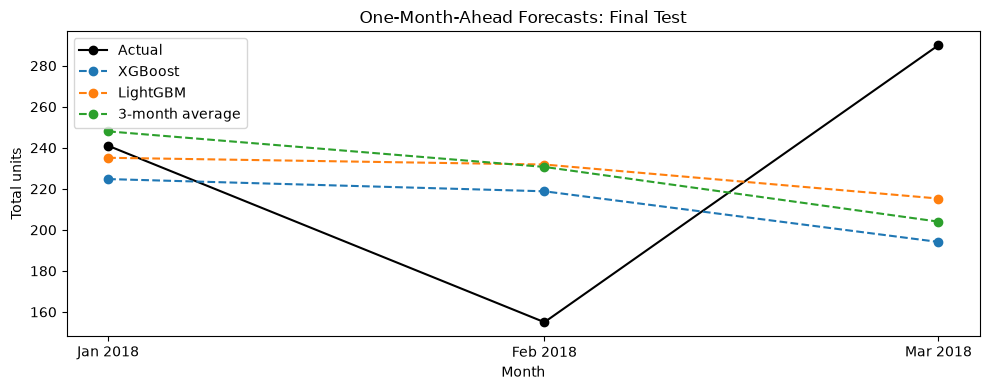

In [24]:
monthly_test = test_predictions.groupby("month_start")[["units_sold"] + prediction_columns].sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_test.index, monthly_test["units_sold"], color="black", marker="o", label="Actual")
for name in ["XGBoost", "LightGBM", "3-month average"]:
    ax.plot(monthly_test.index, monthly_test[name], marker="o", linestyle="--", label=name)
ax.set(title="One-Month-Ahead Forecasts: Final Test", xlabel="Month", ylabel="Total units")
ax.set_xticks(TEST_MONTHS)
ax.set_xticklabels(TEST_MONTHS.strftime("%b %Y"))
ax.legend()
plt.tight_layout()
plt.show()

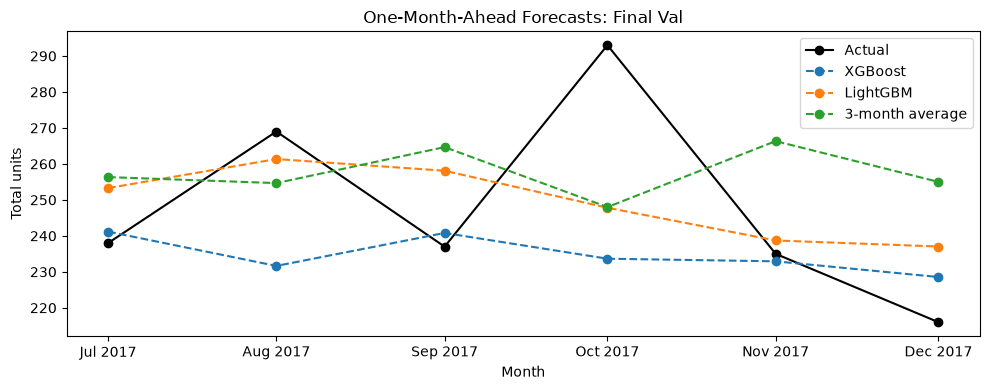

In [29]:
monthly_validation = validation_predictions.groupby("month_start")[["units_sold"] + prediction_columns].sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_validation.index, monthly_validation["units_sold"], color="black", marker="o", label="Actual")
for name in ["XGBoost", "LightGBM", "3-month average"]:
    ax.plot(monthly_validation.index, monthly_validation[name], marker="o", linestyle="--", label=name)
ax.set(title="One-Month-Ahead Forecasts: Final Val", xlabel="Month", ylabel="Total units")
ax.set_xticks(VALIDATION_MONTHS)
ax.set_xticklabels(VALIDATION_MONTHS.strftime("%b %Y"))
ax.legend()
plt.tight_layout()
plt.show()

### Where Does the Selected Model Make Errors?

We calculate average absolute error and bias for each store, category, and store-category pair. A negative bias shows that predictions are too low on average.

In [25]:
errors = test_predictions[keys + ["units_sold"]].copy()
errors["prediction"] = test_predictions[best_model]
errors["error"] = errors["prediction"] - errors["units_sold"]
errors["absolute_error"] = errors["error"].abs()

store_errors = errors.groupby("store_id", as_index=False).agg(
    MAE=("absolute_error", "mean"), Bias=("error", "mean")
)
store_errors = store_errors.merge(store_map, on="store_id")
display(store_errors)

category_errors = errors.groupby("category_id", as_index=False).agg(
    MAE=("absolute_error", "mean"), Bias=("error", "mean")
)
category_errors = category_errors.merge(category_map, on="category_id")
display(category_errors)

,store_id,MAE,Bias,store_name
0,1,2.436,0.591,Santa Cruz Bikes
1,2,8.679,-1.735,Baldwin Bikes
2,3,2.671,-1.158,Rowlett Bikes


,category_id,MAE,Bias,category_name
0,1,5.703,-1.724,Children Bicycles
1,2,3.689,1.260,Comfort Bicycles
2,3,7.138,-1.523,Cruisers Bicycles
3,4,2.236,1.737,Cyclocross Bicycles
4,5,3.137,-2.127,Electric Bikes
5,6,2.901,2.527,Mountain Bikes
6,7,7.364,-5.522,Road Bikes


In [26]:
series_errors = errors.groupby(group_columns, as_index=False).agg(
    MAE=("absolute_error", "mean"), Bias=("error", "mean")
)
display(series_errors.sort_values("MAE", ascending=False))

month_errors = errors.groupby("month_start", as_index=False).agg(
    MAE=("absolute_error", "mean"), Bias=("error", "mean")
)
display(month_errors)

,store_id,category_id,MAE,Bias
13,2,7,16.739,-11.448
9,2,3,12.787,-4.311
7,2,1,9.205,-4.087
12,2,6,7.094,6.069
16,3,3,6.221,-2.664
8,2,2,6.219,3.450
11,2,5,5.175,-4.699
14,3,1,4.450,-2.960
1,1,2,3.853,0.604
10,2,4,3.537,2.883


,month_start,MAE,Bias
0,2018-01-01,4.318,-0.774
1,2018-02-01,4.066,3.038
2,2018-03-01,5.402,-4.566


## 6. Save Results

We save this simpler version's results in `outputs/ml/simple_forecasting`.

In [27]:
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "ml" / "simple_forecasting"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

model_data.to_csv(OUTPUT_DIR / "monthly_features.csv", index=False)
validation_scores.to_csv(OUTPUT_DIR / "validation_scores.csv", index=False)
validation_predictions.to_csv(OUTPUT_DIR / "validation_predictions.csv", index=False)
test_scores.to_csv(OUTPUT_DIR / "test_scores.csv", index=False)
test_predictions.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)
store_errors.to_csv(OUTPUT_DIR / "store_errors.csv", index=False)
category_errors.to_csv(OUTPUT_DIR / "category_errors.csv", index=False)
series_errors.to_csv(OUTPUT_DIR / "series_errors.csv", index=False)
month_errors.to_csv(OUTPUT_DIR / "month_errors.csv", index=False)
print("Results saved to:", OUTPUT_DIR)

Results saved to: c:\Users\okand\Desktop\Projects\Bikestores Analytics\outputs\ml\simple_forecasting


### Conclusion

The result below uses the model chosen during validation. The three-month average is the strongest baseline from the earlier validation comparison.

This test covers only three months. More history or new months would give stronger evidence. Old row-based scores are not directly comparable with this time-based evaluation.

In [28]:
scores_by_model = test_scores.set_index("Model")
model_mae = scores_by_model.loc[best_model, "MAE"]
baseline_mae = scores_by_model.loc["3-month average", "MAE"]

print("Selected model:", best_model)
print(f"Test MAE: {model_mae:.3f} units")
print(f"3-month average MAE: {baseline_mae:.3f} units")
if baseline_mae > 0:
    improvement = 100 * (baseline_mae - model_mae) / baseline_mae
    print(f"MAE improvement versus the baseline: {improvement:.1f}%")

Selected model: XGBoost
Test MAE: 4.596 units
3-month average MAE: 5.090 units
MAE improvement versus the baseline: 9.7%
